# Gene statistics

Were we summarize some annotation statistics with a focus on intron ratios, as considered by [Glick et al. 2024](http://dx.doi.org/10.1093/molbev/msae248). They define the intron ratio of each gene as "the ratio between the total intron and total exon lengths of a gene". 

A few details on their calculation and presentation of intron ratios:

- They then summarize the intron ratios of all genes in a genome by taking the average across all genes.
- "Intronless genes were retained in all analyses, unless indicated otherwise." They were explicitly excluded from Figure 1.
- Intron ratios were log10 transformed for figures and evolutionary analyses, eg "To avoid values varying by orders of magnitude while fitting the models, log10 transformation was applied to all gene structure features except for the number of introns."
- Intron ratios were not log10 transformed in the [supp_tables.xlsx](https://academic.oup.com/mbe/article/41/12/msae248/7918795#supplementary-data) that includes all statistics for all species. This not explicit, but is evident because there are no negative values in the `Mean intron ratio` column though there are negative values in the figures of log transformed data.
- Intron ratios reported in the text are not log10 transformed. This is evident because spot checked values are identical to the values in the supplementary table that are not log10 transformed.

We consider stats for the siphonophore *Nanomia septata*, and the siphonophore outgroup member *Hydractinia symbiologicarpus* that was not in the Glick et al. study. We then comapre these two taxa to the broader dataset compiled by Glick et al. 2024.

## *Nanomia septata*

### Load data


In [1]:
import gene_stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

prefix = "NSv0.8_hap2_LG"
gff_file = "./Nanomia_septata.v0.8.gff"

In [2]:
# Call the main function and store the returned DataFrames
df_genes, df_exons, df_introns = gene_stats.gene_stats(gff_file, prefix)

Reading file: ./Nanomia_septata.v0.8.gff
File type: FileType.GFF
Number of rows read: 244529
Number of rows after removing duplicates: 244529
Number of rows after filtering by prefix: 244529


In [3]:
# print the first few rows of each DataFrame
print("Genes DataFrame:")
print(df_genes.head())
print("\nExons DataFrame:")
print(df_exons.head())
print("\nIntrons DataFrame:")
print(df_introns.head())


Genes DataFrame:
              seqid source  type    start      end score strand phase  \
2   NSv0.8_hap2_LG1  maker  gene   193111   193533     .      -     .   
6   NSv0.8_hap2_LG1  maker  gene   808002   808783     .      +     .   
12  NSv0.8_hap2_LG1  maker  gene  1356349  1361772     .      -     .   
16  NSv0.8_hap2_LG1  maker  gene  1751120  1751565     .      +     .   
22  NSv0.8_hap2_LG1  maker  gene  1751667  1753534     .      +     .   

                                           attributes   gene_ID        ID  \
2       ID=ANN00001;Note=Protein of unknown function;  ANN00001  ANN00001   
6   ID=ANN00002;Note=Similar to Fcn1: Ficolin-1 (R...  ANN00002  ANN00002   
12  ID=ANN00003;Note=Similar to pol: Pro-Pol polyp...  ANN00003  ANN00003   
16      ID=ANN00004;Note=Protein of unknown function;  ANN00004  ANN00004   
22      ID=ANN00005;Note=Protein of unknown function;  ANN00005  ANN00005   

   Parent                                               Note  length  \
2     NaN

### Intron ratios



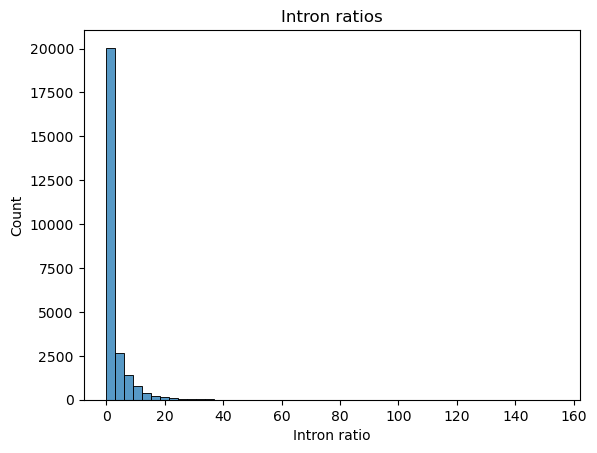

In [4]:
# Histogram of intron ratios
plt.figure()
sns.histplot(df_genes["intron_ratio"], bins=50)
plt.title("Intron ratios")
plt.xlabel("Intron ratio")
plt.ylabel("Count")
plt.show()

In [5]:
# Mean intron ratio
mean_intron_ratio = df_genes["intron_ratio"].mean()
print(f"Mean intron ratio: {mean_intron_ratio:.4f}")

Mean intron ratio: 2.3027


We also calculate the intron ratio as the ratio of the total intron length to the total exon length. This is distinct from the method of Glick et al. 2024, who take the average of the ratios for each gene.

In [6]:
length_introns = df_introns["length"].sum()
length_exons = df_exons["length"].sum()
length_genes = df_genes["length"].sum()
print(f"Total intron length: {length_introns/1e6} Mb")
print(f"Total exon length: {length_exons/1e6} Mb")
print(f"Total gene length: {length_genes/1e6} Mb")
print(f"Intron ratio: {length_introns/length_exons:.2f}")

Total intron length: 71.34607 Mb
Total exon length: 37.371148 Mb
Total gene length: 110.427467 Mb
Intron ratio: 1.91


### Other statistics

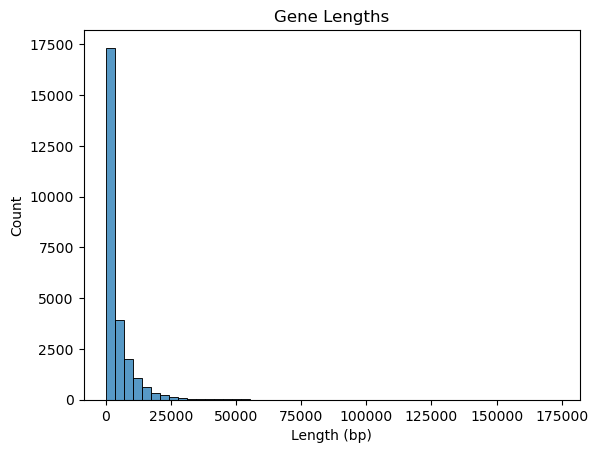

In [7]:
# Histogram of gene lengths
plt.figure()
sns.histplot(df_genes["length"], bins=50)
plt.title("Gene Lengths")
plt.xlabel("Length (bp)")
plt.ylabel("Count")
plt.show()

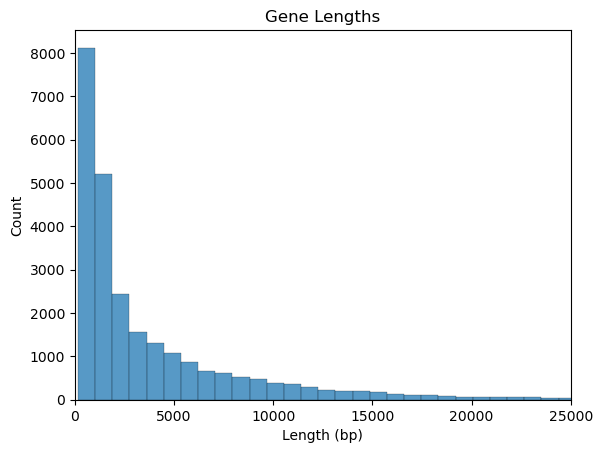

In [8]:
# Histogram of gene lengths up to 25000 bp

plt.figure()
sns.histplot(df_genes["length"], bins=200)
plt.xlim(0, 25000)
plt.title("Gene Lengths")
plt.xlabel("Length (bp)")
plt.ylabel("Count")
plt.show()

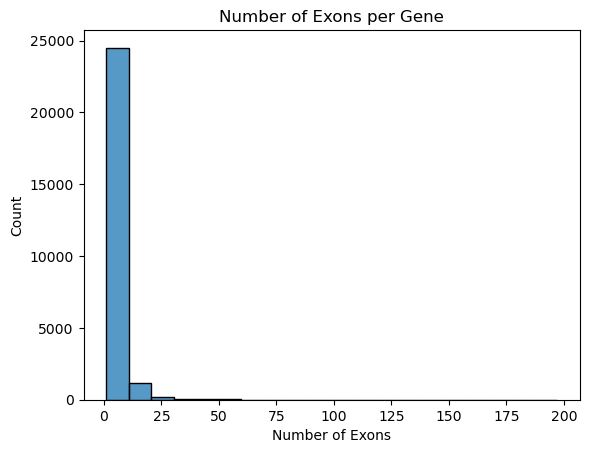

In [9]:
# histogram of number of exons per gene
plt.figure()
sns.histplot(df_genes["num_exons"], bins=20)
plt.title("Number of Exons per Gene")
plt.xlabel("Number of Exons")
plt.ylabel("Count")
plt.show()

## *Hydractinia symbiologicarpus*

To get statistics for a closely related outgroup taxon, we ingest and analyze gene annotations from HSymV2.0.gtf at https://figshare.com/articles/dataset/HSymV2_0_a_chromosome-level_genome_assembly_of_Hydractinia_symbiolongicarpus/22126232/1?file=39369317 .

In [10]:
# Call the main function and store the returned DataFrames
df_genes_hydractinia, df_exons_hydractinia, df_introns_hydractinia = gene_stats.gene_stats("HSymV2.0.gtf", prefix=None)

# Display the intron ratio, ie the total length of introns divided by total length of exons
length_introns_hydractinia = df_introns_hydractinia["length"].sum()
length_exons_hydractinia = df_exons_hydractinia["length"].sum()
length_genes_hydractinia = df_genes_hydractinia["length"].sum()
print(f"Total intron length: {length_introns_hydractinia/1e6} Mb")
print(f"Total exon length: {length_exons_hydractinia/1e6} Mb")
print(f"Total gene length: {length_genes_hydractinia/1e6} Mb")
print(f"Mean Intron ratio: {df_genes_hydractinia['intron_ratio'].mean():.4f}")
print(f"Global intron ratio: {length_introns_hydractinia/length_exons_hydractinia:.2f}")


Reading file: HSymV2.0.gtf
File type: FileType.GTF
Number of rows read: 421084
Number of rows after removing duplicates: 412337
Total intron length: 107.387182 Mb
Total exon length: 39.333974 Mb
Total gene length: 151.192974 Mb
Mean Intron ratio: 2.7385
Global intron ratio: 2.73


## Cross species intron ratio analyses

We added *Nanomia septata* and *Hydractinia symbiolongicarpus* intron ratios to the dataset of Glick et al 2024 - https://doi.org/10.1093/molbev/msae248

In [11]:
df_glick = pd.read_csv("supp_tables_glick2024_modified.csv")

print(df_glick.shape)

(592, 16)


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

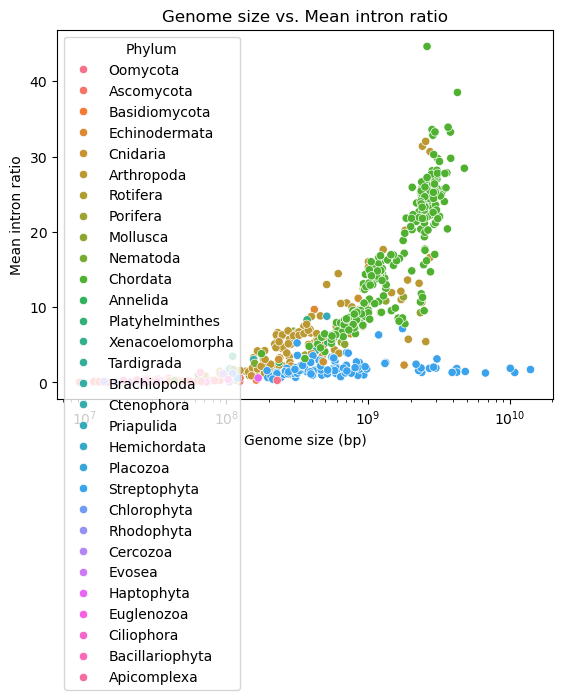

In [13]:
# Use seaborn to make a scatter plot of `Genome size` on x and `Mean intron ratio` on y and color points by `Phylum`

plt.figure()
sns.scatterplot(data=df_glick, x="Genome size", y="Mean intron ratio", hue="Phylum")
plt.xscale("log")
#plt.yscale("log")
plt.xlabel("Genome size (bp)")
plt.ylabel("Mean intron ratio")
plt.title("Genome size vs. Mean intron ratio")

# Add a legend with a title to sidebar
plt.legend(title="Phylum")

plt.show()

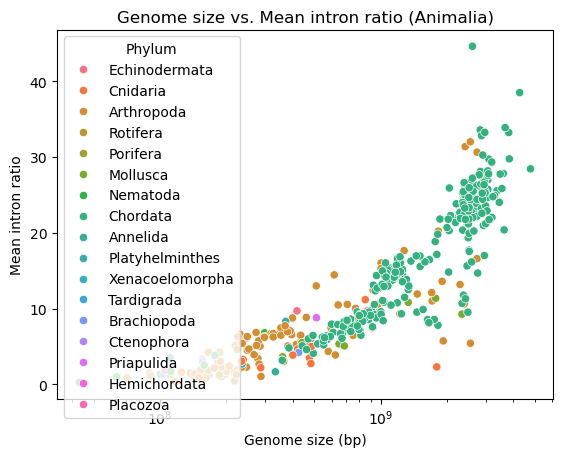

In [14]:
df_animalia = df_glick[df_glick["Kingdom"] == "Animalia"]

plt.figure()
sns.scatterplot(data=df_animalia, x="Genome size", y="Mean intron ratio", hue="Phylum")
plt.xscale("log")
#plt.yscale("log")
plt.xlabel("Genome size (bp)")
plt.ylabel("Mean intron ratio")
plt.title("Genome size vs. Mean intron ratio (Animalia)")
plt.legend(title="Phylum")
plt.show()

In [15]:
# Make a table of the unique Phyla in the Animalia and the number or rows for each
print(df_animalia["Phylum"].value_counts())

Phylum
Chordata           255
Arthropoda         112
Cnidaria            12
Mollusca            11
Nematoda            10
Echinodermata        5
Annelida             3
Platyhelminthes      2
Porifera             1
Rotifera             1
Xenacoelomorpha      1
Tardigrada           1
Brachiopoda          1
Ctenophora           1
Priapulida           1
Hemichordata         1
Placozoa             1
Name: count, dtype: int64


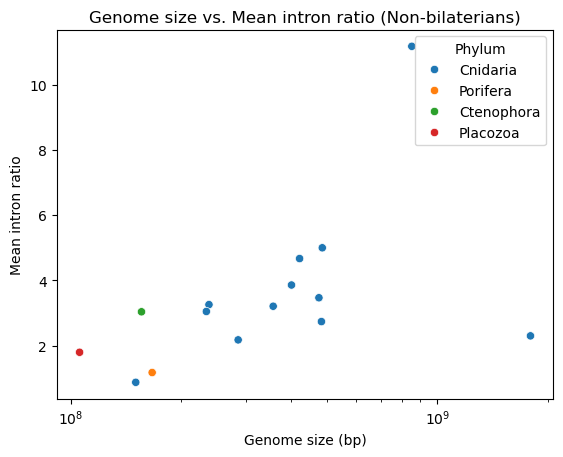

In [16]:
# subset to only include non-bilaterians
nonbilateria = ["Cnidaria", "Porifera", "Placozoa", "Ctenophora"]
df_nonbilat = df_animalia[df_animalia["Phylum"].isin(nonbilateria)]

plt.figure()
sns.scatterplot(data=df_nonbilat, x="Genome size", y="Mean intron ratio", hue="Phylum")
plt.xscale("log")
#plt.yscale("log")
plt.xlabel("Genome size (bp)")
plt.ylabel("Mean intron ratio")
plt.title("Genome size vs. Mean intron ratio (Non-bilaterians)")
plt.legend(title="Phylum")
plt.show()

In [17]:
# Print the non bilaterian species and their mean intron ratio, order by decreasing intron ratio
df_nonbilat = df_nonbilat.sort_values("Mean intron ratio", ascending=False)
print(df_nonbilat[["species", "Mean intron ratio"]])

                           species  Mean intron ratio
142                 hydra_vulgaris            11.1700
166            orbicella_faveolata             5.0000
98            clytia_hemisphaerica             4.6700
200          stylophora_pistillata             3.8600
50              acropora_millepora             3.4700
51               actinia_tenebrosa             3.2600
162         nematostella_vectensis             3.2100
177         pocillopora_damicornis             3.0500
158              mnemiopsis_leidyi             3.0400
591  hydractinia_symbiolongicarpus             2.7400
590                nanomia_septata             2.3027
107        dendronephthya_gigantea             2.1800
208           trichoplax_adhaerens             1.8000
58        amphimedon_queenslandica             1.1800
203          thelohanellus_kitauei             0.8800


There is no strong relationship between intron ratio and genome size within Cnidaria. Check some other animals.

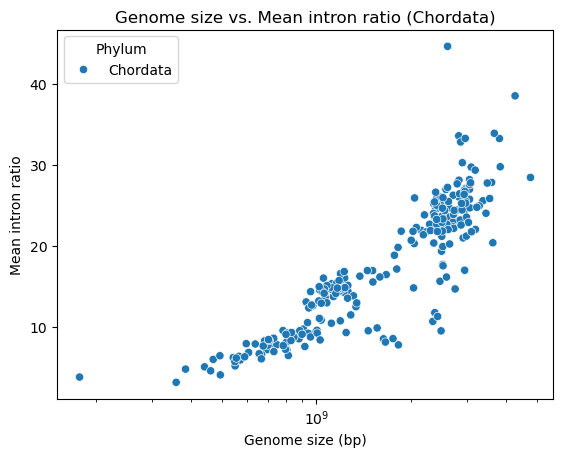

In [18]:
# plot Chordata separately
df_chordata = df_animalia[df_animalia["Phylum"] == "Chordata"]

plt.figure()
sns.scatterplot(data=df_chordata, x="Genome size", y="Mean intron ratio", hue="Phylum")
plt.xscale("log")
#plt.yscale("log")
plt.xlabel("Genome size (bp)")
plt.ylabel("Mean intron ratio")
plt.title("Genome size vs. Mean intron ratio (Chordata)")

# Add a legend with a title to sidebar
plt.legend(title="Phylum")

plt.show()

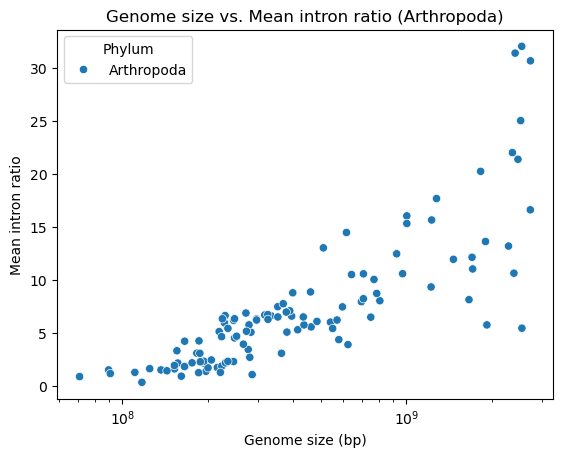

In [19]:
# same for arthropoda

df_arthropoda = df_animalia[df_animalia["Phylum"] == "Arthropoda"]

plt.figure()
sns.scatterplot(data=df_arthropoda, x="Genome size", y="Mean intron ratio", hue="Phylum")
plt.xscale("log")
plt.xlabel("Genome size (bp)")
plt.ylabel("Mean intron ratio")
plt.title("Genome size vs. Mean intron ratio (Arthropoda)")
plt.legend(title="Phylum")
plt.show()

Other phyla don't have many species in the dataset.

A few observations:
- Within these groups there are very large genomes with low intron ratios, so intron ratios often do not increase much with genome size.
- Some large genomes have large intron ratios compared to animals with small genomes, but it is far from universal.